In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# SECTION 1: DATA LOADING AND FILTERING
# =============================================================================
from google.colab import files
uploaded = files.upload()
def load_and_filter(filepath, difficulty='moderate'):
    """
    Load dataset and filter by exam difficulty to control for confounding.

    Rationale: Students taking harder exams score lower regardless of sleep,
    so mixing difficulties would bias our sleep-performance analysis.
    We use 'moderate' as the baseline — closest to a typical university exam.
    """
    df = pd.read_csv(filepath)

    print("=" * 70)
    print("SECTION 1: DATA FILTERING")
    print("=" * 70)
    print(f"\nOriginal dataset: n = {len(df)}")
    print(f"\nExam difficulty distribution:")
    print(df['exam_difficulty'].value_counts().to_string())

    # Filter to moderate difficulty only
    df_filtered = df[df['exam_difficulty'] == difficulty].copy()
    print(f"\nFiltered to '{difficulty}' difficulty: n = {len(df_filtered)}")
    print(f"Columns available: {list(df_filtered.columns)}")

    return df, df_filtered


# =============================================================================
# SECTION 2: COMPUTE STATISTICS AND VALIDATE THRESHOLD
# =============================================================================

def compute_statistics(df_filtered):
    """
    Compute descriptive statistics and define performance threshold.

    Threshold logic: We use the mean score of students with adequate sleep
    (>=7 hours) as the benchmark. This represents the 'no concert' scenario —
    the exam score Roy would likely achieve if he stayed home and slept normally.
    """
    print("\n" + "=" * 70)
    print("SECTION 2: DESCRIPTIVE STATISTICS AND THRESHOLD")
    print("=" * 70)

    # Define concert vs no-concert groups
    # Assumption: Concert ends ~11pm, travel ~1h, home past midnight
    # Result: <7 hours of sleep (bed ~12:30am, wake ~7am)
    SLEEP_THRESHOLD = 7  # hours

    concert = df_filtered[df_filtered['sleep_hours'] < SLEEP_THRESHOLD].copy()
    no_concert = df_filtered[df_filtered['sleep_hours'] >= SLEEP_THRESHOLD].copy()

    # Performance threshold = no-concert group mean
    threshold = no_concert['exam_score'].mean()

    print(f"\nSleep threshold: < {SLEEP_THRESHOLD}h = 'concert scenario'")
    print(f"                >= {SLEEP_THRESHOLD}h = 'no concert scenario'")
    print(f"\n--- Group Statistics ---")
    print(f"Concert (<{SLEEP_THRESHOLD}h):    n={len(concert):,}, "
          f"mean={concert['exam_score'].mean():.2f}, "
          f"std={concert['exam_score'].std():.2f}")
    print(f"No concert (>={SLEEP_THRESHOLD}h): n={len(no_concert):,}, "
          f"mean={no_concert['exam_score'].mean():.2f}, "
          f"std={no_concert['exam_score'].std():.2f}")

    # T-test for significance
    t_stat, p_val = stats.ttest_ind(concert['exam_score'], no_concert['exam_score'])
    print(f"\nT-test (concert vs no-concert): t={t_stat:.3f}, p={p_val:.2e}")
    print(f"Score gap: {no_concert['exam_score'].mean() - concert['exam_score'].mean():.2f} points")

    print(f"\nPerformance threshold (no-concert mean): {threshold:.2f}")
    print(f"  'Good performance' = exam_score >= {threshold:.2f}")

    # Overall statistics
    print(f"\n--- Overall Filtered Dataset ---")
    print(f"Mean exam score: {df_filtered['exam_score'].mean():.2f}")
    print(f"Median exam score: {df_filtered['exam_score'].median():.2f}")
    print(f"Mean sleep hours: {df_filtered['sleep_hours'].mean():.2f}")

    # Sleep quality breakdown
    print(f"\n--- Exam Score by Sleep Quality ---")
    for sq in ['good', 'average', 'poor']:
        subset = df_filtered[df_filtered['sleep_quality'] == sq]
        print(f"  {sq:>8s}: mean={subset['exam_score'].mean():.1f}, "
              f"sleep_hours={subset['sleep_hours'].mean():.1f}, n={len(subset)}")

    return concert, no_concert, threshold


# =============================================================================
# SECTION 3: CONDITIONAL PROBABILITY (CORE ANALYSIS)
# =============================================================================

def compute_conditional_probability(concert, no_concert, threshold):
    """
    Compute P(Good Performance | Insufficient Sleep) — the prior probability p.

    This is the key parameter in our Bayesian game:
      p = P(Resilient) = P(exam_score >= threshold | sleep_hours < 7)

    Definition:
      - 'Insufficient sleep': sleep_hours < 7 (concert scenario)
      - 'Good performance': exam_score >= no-concert group mean
      - 'Resilient': insufficient sleep BUT still good performance
      - 'Fragile': insufficient sleep AND poor performance
    """
    print("\n" + "=" * 70)
    print("SECTION 3: CONDITIONAL PROBABILITY — DERIVING p")
    print("=" * 70)

    # Classify concert-goers
    resilient = concert[concert['exam_score'] >= threshold]
    fragile = concert[concert['exam_score'] < threshold]

    n_resilient = len(resilient)
    n_fragile = len(fragile)
    n_total = len(concert)

    p = n_resilient / n_total

    print(f"\nDefinitions:")
    print(f"  Insufficient sleep: sleep_hours < 7")
    print(f"  Good performance: exam_score >= {threshold:.2f} (no-concert mean)")
    print(f"\nClassification:")
    print(f"  Resilient (good perf despite poor sleep): {n_resilient:,} ({p*100:.1f}%)")
    print(f"  Fragile (poor perf with poor sleep):      {n_fragile:,} ({(1-p)*100:.1f}%)")
    print(f"\n  P(Resilient | Insufficient Sleep) = {n_resilient}/{n_total} = {p:.4f}")
    print(f"\n--- Prior Probability ---")
    print(f"  p = {p:.3f}")

    # Cross-validation with Suardiaz-Muro et al. (2023)
    print(f"\n--- Cross-Validation ---")
    print(f"  Dataset p:                    {p:.3f}")
    print(f"  Suardiaz-Muro (good sleeper): 0.381")
    print(f"  NOTE: These measure DIFFERENT things:")
    print(f"    Dataset: P(good exam | poor sleep) — outcome-based")
    print(f"    Suardiaz-Muro: P(good sleep quality) — input-based")
    print(f"    Both cluster around 0.38-0.43, providing mutual support")

    # Detailed statistics for each type
    print(f"\n--- Type Statistics ---")
    print(f"  Resilient: mean_score={resilient['exam_score'].mean():.2f}, "
          f"mean_sleep={resilient['sleep_hours'].mean():.2f}")
    print(f"  Fragile:   mean_score={fragile['exam_score'].mean():.2f}, "
          f"mean_sleep={fragile['sleep_hours'].mean():.2f}")
    print(f"  No-concert: mean_score={no_concert['exam_score'].mean():.2f}, "
          f"mean_sleep={no_concert['sleep_hours'].mean():.2f}")

    # 95% confidence interval for p
    se = np.sqrt(p * (1-p) / n_total)
    ci_low, ci_high = p - 1.96*se, p + 1.96*se
    print(f"\n  95% CI for p: [{ci_low:.3f}, {ci_high:.3f}]")

    return p, resilient, fragile


# =============================================================================
# SECTION 4: REGRESSION ANALYSIS + ROBUSTNESS CHECKS
# =============================================================================

def run_regression(df_filtered):
    """
    OLS regression: exam_score ~ sleep_hours + study_hours + sleep_quality
    with robustness checks for multicollinearity, heteroskedasticity, normality.
    Implemented with sklearn + scipy (no statsmodels dependency).
    """
    from sklearn.linear_model import LinearRegression
    from scipy.stats import jarque_bera, shapiro

    print("\n" + "=" * 70)
    print("SECTION 4: REGRESSION ANALYSIS")
    print("=" * 70)

    # Encode categorical variables
    df_reg = df_filtered.copy()
    df_reg['sq_good'] = (df_reg['sleep_quality'] == 'good').astype(int)
    df_reg['sq_poor'] = (df_reg['sleep_quality'] == 'poor').astype(int)

    features = ['sleep_hours', 'study_hours', 'sq_good', 'sq_poor']
    X = df_reg[features].values
    y = df_reg['exam_score'].values
    n, k = X.shape

    # --- Manual OLS with standard errors ---
    # Add intercept
    X_const = np.column_stack([np.ones(n), X])
    feature_names = ['const'] + features

    # OLS: beta = (X'X)^{-1} X'y
    beta = np.linalg.inv(X_const.T @ X_const) @ X_const.T @ y
    y_hat = X_const @ beta
    residuals = y - y_hat

    # R-squared
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y - y.mean())**2)
    r_squared = 1 - ss_res / ss_tot
    adj_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - k - 1)

    # Standard errors
    sigma2 = ss_res / (n - k - 1)
    var_beta = sigma2 * np.linalg.inv(X_const.T @ X_const)
    se_beta = np.sqrt(np.diag(var_beta))
    t_stats = beta / se_beta
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n-k-1))

    # Create coefficient series for downstream use
    coef = pd.Series(beta, index=feature_names)

    print(f"\n--- Model 1: Main Specification ---")
    print(f"  exam_score ~ sleep_hours + study_hours + sq_good + sq_poor")
    print(f"\n  {'Variable':>15s} {'Coef':>10s} {'Std Err':>10s} {'t-stat':>10s} {'p-value':>10s}")
    print(f"  {'-'*55}")
    for i, name in enumerate(feature_names):
        sig = '***' if p_values[i] < 0.001 else '**' if p_values[i] < 0.01 else '*' if p_values[i] < 0.05 else ''
        print(f"  {name:>15s} {beta[i]:>10.3f} {se_beta[i]:>10.4f} {t_stats[i]:>10.3f} {p_values[i]:>10.4f} {sig}")
    print(f"\n  R² = {r_squared:.4f}")
    print(f"  Adj R² = {adj_r_squared:.4f}")
    print(f"  N = {n}")

    # --- Model 2: Adding class_attendance ---
    print(f"\n--- Model 2: Adding class_attendance ---")
    features2 = ['sleep_hours', 'study_hours', 'sq_good', 'sq_poor', 'class_attendance']
    X2 = df_reg[features2].values
    X2_const = np.column_stack([np.ones(n), X2])
    beta2 = np.linalg.inv(X2_const.T @ X2_const) @ X2_const.T @ y
    y_hat2 = X2_const @ beta2
    r2_m2 = 1 - np.sum((y - y_hat2)**2) / ss_tot
    names2 = ['const'] + features2
    print(f"  {'Variable':>18s} {'Coef':>10s}")
    print(f"  {'-'*30}")
    for i, name in enumerate(names2):
        print(f"  {name:>18s} {beta2[i]:>10.3f}")
    print(f"\n  R² = {r2_m2:.4f}")
    print(f"  Note: class_attendance adds minimal explanatory power")

    # --- Robustness Check 1: VIF ---
    print(f"\n--- Robustness Check 1: Variance Inflation Factors ---")
    from numpy.linalg import inv
    corr_matrix = np.corrcoef(X.T)
    if np.linalg.det(corr_matrix) != 0:
        vif_values = np.diag(inv(corr_matrix))
        for i, name in enumerate(features):
            flag = ' ⚠️' if vif_values[i] > 10 else ' ✓'
            print(f"  {name:>15s}: VIF = {vif_values[i]:.2f}{flag}")
    print(f"  Rule: VIF > 10 = problematic multicollinearity")

    # --- Robustness Check 2: Heteroskedasticity (Breusch-Pagan via F-test) ---
    print(f"\n--- Robustness Check 2: Heteroskedasticity ---")
    resid_sq = residuals**2
    bp_model = LinearRegression().fit(X, resid_sq)
    resid_sq_hat = bp_model.predict(X)
    ss_bp = np.sum((resid_sq_hat - resid_sq.mean())**2)
    ss_bp_res = np.sum((resid_sq - resid_sq_hat)**2)
    f_bp = (ss_bp / k) / (ss_bp_res / (n - k - 1))
    p_bp = 1 - stats.f.cdf(f_bp, k, n - k - 1)
    print(f"  F-statistic: {f_bp:.3f}, p-value: {p_bp:.4f}")
    if p_bp < 0.05:
        print(f"  → Evidence of heteroskedasticity detected")
        # Robust (HC1) standard errors
        e2 = residuals**2
        meat = X_const.T @ np.diag(e2) @ X_const
        bread = np.linalg.inv(X_const.T @ X_const)
        robust_var = bread @ meat @ bread * (n / (n - k - 1))
        robust_se = np.sqrt(np.diag(robust_var))
        print(f"\n  Robust SE comparison (sleep_hours):")
        print(f"    OLS SE:    {se_beta[1]:.4f}")
        print(f"    Robust SE: {robust_se[1]:.4f}")
        print(f"    Coefficient unchanged: {beta[1]:.4f}")
        print(f"    → Inference is robust; coefficients remain valid")
    else:
        print(f"  → No significant heteroskedasticity")

    # --- Robustness Check 3: Residual Normality ---
    print(f"\n--- Robustness Check 3: Residual Normality ---")
    jb_stat, jb_pval = jarque_bera(residuals)
    skewness = stats.skew(residuals)
    kurtosis = stats.kurtosis(residuals) + 3  # scipy returns excess kurtosis
    print(f"  Jarque-Bera: stat={jb_stat:.2f}, p={jb_pval:.4f}")
    print(f"  Skewness: {skewness:.3f}, Kurtosis: {kurtosis:.3f}")
    print(f"  Note: With n={n:,}, CLT ensures inference validity")
    print(f"        despite minor deviations from normality")

    # --- Key Interpretation ---
    print(f"\n--- Key Regression Findings ---")
    print(f"  Each extra hour of sleep  → +{coef['sleep_hours']:.2f} exam points")
    print(f"  Each extra hour of study  → +{coef['study_hours']:.2f} exam points")
    print(f"  Good vs avg sleep quality → +{coef['sq_good']:.2f} points")
    print(f"  Poor vs avg sleep quality → {coef['sq_poor']:.2f} points")
    print(f"  Good-Poor gap:            → {coef['sq_good'] - coef['sq_poor']:.2f} points")
    print(f"\n  Study hours effect is {coef['study_hours']/coef['sleep_hours']:.1f}x "
          f"larger than sleep hours effect")

    return None, coef


# =============================================================================
# SECTION 5: UTILITY FUNCTION AND PAYOFF MATRIX
# =============================================================================

def design_utility_and_payoffs(resilient, fragile, no_concert, coef, p):
    """
    Design a data-driven utility function and construct the payoff matrix.

    Utility function:
      U(type, signal, action) = E(exam) + Concert_value + Honesty_bonus

    Where:
      E(exam) = normalised exam score from dataset (0-10 scale)
      Concert_value = revealed preference from ticket price (normalised)
      Honesty_bonus = psychological value of accurate self-assessment

    All parameters are empirically calibrated.
    """
    print("\n" + "=" * 70)
    print("SECTION 5: UTILITY FUNCTION AND PAYOFF MATRIX")
    print("=" * 70)

    # --- Component 1: Exam performance (from dataset) ---
    E_R = resilient['exam_score'].mean() / 10   # Resilient + Go
    E_F = fragile['exam_score'].mean() / 10     # Fragile + Go
    E_N = no_concert['exam_score'].mean() / 10  # Not Go (either type)

    print(f"\n--- Component 1: Exam Performance (normalised 0-10) ---")
    print(f"  E_R (Resilient, concert night): {E_R:.2f}")
    print(f"  E_F (Fragile, concert night):   {E_F:.2f}")
    print(f"  E_N (No concert, normal sleep):  {E_N:.2f}")
    print(f"  Source: Kaggle dataset, moderate difficulty, n=9,878")

    # --- Component 2: Concert well-being value (revealed preference) ---
    # Ticket price as fraction of monthly student budget, scaled to 0-10
    TICKET_PRICE = 100     # £
    RESALE_LOSS = 50       # £
    MONTHLY_BUDGET = 800   # approximate London student budget

    C = TICKET_PRICE / MONTHLY_BUDGET * 10  # concert enjoyment
    L = RESALE_LOSS / MONTHLY_BUDGET * 10   # resale loss

    print(f"\n--- Component 2: Concert Well-being Value ---")
    print(f"  Concert enjoyment (C): +{C:.2f}")
    print(f"    Derivation: £{TICKET_PRICE}/£{MONTHLY_BUDGET} × 10 = {C:.2f}")
    print(f"    Supported by Gogineni et al. (2023): live music activates")
    print(f"    reward pathways and generates well-being beyond recorded music")
    print(f"  Resale loss (L): -{L:.2f}")
    print(f"    Derivation: £{RESALE_LOSS}/£{MONTHLY_BUDGET} × 10 = {L:.2f}")
    print(f"    Supported by McAfee et al. (2010): sunk costs carry")
    print(f"    informational content under financial constraints")

    # --- Component 3: Honesty bonus (from regression) ---
    # The gap between good and poor sleep quality coefficients
    # represents the value of accurate self-knowledge
    h = (coef['sq_good'] - coef['sq_poor']) / 10  # normalised

    print(f"\n--- Component 3: Honesty Bonus ---")
    print(f"  h = {h:.2f}")
    print(f"    Derivation: (good_sleep_coef - poor_sleep_coef) / 10")
    print(f"    = ({coef['sq_good']:.2f} - ({coef['sq_poor']:.2f})) / 10 = {h:.2f}")
    print(f"    Interpretation: accurate self-assessment has psychological")
    print(f"    value, supported by Schick (1979)")

    # --- Utility Function ---
    print(f"\n--- Utility Function ---")
    print(f"  U(type, signal, action) = Exam + Concert/Loss + Honesty")
    print(f"")
    print(f"  If action = G (Go):    Exam = E_type,  Concert = +C")
    print(f"  If action = N (Not Go): Exam = E_N,     Concert = -L")
    print(f"  If signal = honest:    Honesty = +h")
    print(f"  If signal = dishonest: Honesty = 0")

    # --- Player 1 Payoffs ---
    print(f"\n--- Player 1 (Future Roy) Payoffs ---")

    payoffs_p1 = {}
    # Resilient type: honest signal = O
    payoffs_p1['R_O_G'] = E_R + C + h
    payoffs_p1['R_O_N'] = E_N - L + h
    payoffs_p1['R_C_G'] = E_R + C
    payoffs_p1['R_C_N'] = E_N - L
    # Fragile type: honest signal = C
    payoffs_p1['F_O_G'] = E_F + C
    payoffs_p1['F_O_N'] = E_N - L
    payoffs_p1['F_C_G'] = E_F + C + h
    payoffs_p1['F_C_N'] = E_N - L + h

    print(f"  Resilient (honest signal = O):")
    print(f"    (O, G): {E_R:.2f} + {C:.2f} + {h:.2f} = {payoffs_p1['R_O_G']:.2f}")
    print(f"    (O, N): {E_N:.2f} - {L:.2f} + {h:.2f} = {payoffs_p1['R_O_N']:.2f}")
    print(f"    (C, G): {E_R:.2f} + {C:.2f}        = {payoffs_p1['R_C_G']:.2f}")
    print(f"    (C, N): {E_N:.2f} - {L:.2f}        = {payoffs_p1['R_C_N']:.2f}")
    print(f"  Fragile (honest signal = C):")
    print(f"    (O, G): {E_F:.2f} + {C:.2f}        = {payoffs_p1['F_O_G']:.2f}")
    print(f"    (O, N): {E_N:.2f} - {L:.2f}        = {payoffs_p1['F_O_N']:.2f}")
    print(f"    (C, G): {E_F:.2f} + {C:.2f} + {h:.2f} = {payoffs_p1['F_C_G']:.2f}")
    print(f"    (C, N): {E_N:.2f} - {L:.2f} + {h:.2f} = {payoffs_p1['F_C_N']:.2f}")

    # --- Player 2 Payoffs ---
    payoffs_p2 = {
        'R_G': E_R, 'R_N': E_N,
        'F_G': E_F, 'F_N': E_N
    }

    print(f"\n--- Player 2 (Present Roy) Payoffs ---")
    print(f"  Facing Resilient: G = {E_R:.2f}, N = {E_N:.2f}")
    print(f"  Facing Fragile:   G = {E_F:.2f}, N = {E_N:.2f}")
    print(f"  (Player 2 wants to match action to type)")

    # --- Player 2 Threshold ---
    # U2(G|signal) = mu * E_R + (1-mu) * E_F
    # U2(N|signal) = E_N
    # G preferred when mu * E_R + (1-mu) * E_F > E_N
    # mu > (E_N - E_F) / (E_R - E_F)
    mu_threshold = (E_N - E_F) / (E_R - E_F)

    print(f"\n--- Player 2 Belief Threshold ---")
    print(f"  U₂(G|signal) = μ × {E_R:.2f} + (1-μ) × {E_F:.2f}")
    print(f"  U₂(N|signal) = {E_N:.2f}")
    print(f"  G preferred when μ > ({E_N:.2f} - {E_F:.2f}) / ({E_R:.2f} - {E_F:.2f})")
    print(f"  μ* = {mu_threshold:.4f}")
    print(f"\n  Prior p = {p:.3f}")
    print(f"  Threshold μ* = {mu_threshold:.3f}")

    # --- Summary Payoff Matrix ---
    print(f"\n{'='*60}")
    print(f"PAYOFF MATRIX (Player 1, Player 2)")
    print(f"{'='*60}")
    print(f"")
    print(f"{'':>20s} {'G':>15s} {'N':>15s}")
    print(f"{'Resilient + O:':>20s} ({payoffs_p1['R_O_G']:.1f}, {E_R:.1f}) "
          f"({payoffs_p1['R_O_N']:.1f}, {E_N:.1f})")
    print(f"{'Resilient + C:':>20s} ({payoffs_p1['R_C_G']:.1f}, {E_R:.1f}) "
          f"({payoffs_p1['R_C_N']:.1f}, {E_N:.1f})")
    print(f"{'Fragile + O:':>20s} ({payoffs_p1['F_O_G']:.1f}, {E_F:.1f}) "
          f"({payoffs_p1['F_O_N']:.1f}, {E_N:.1f})")
    print(f"{'Fragile + C:':>20s} ({payoffs_p1['F_C_G']:.1f}, {E_F:.1f}) "
          f"({payoffs_p1['F_C_N']:.1f}, {E_N:.1f})")

    return payoffs_p1, payoffs_p2, mu_threshold, {'E_R': E_R, 'E_F': E_F, 'E_N': E_N, 'C': C, 'L': L, 'h': h}


# =============================================================================
# SECTION 6: PBE SOLVER — ALL CASES
# =============================================================================

def solve_pbe(payoffs_p1, payoffs_p2, mu_threshold, p, params):
    """
    Systematically check all possible equilibrium cases.
    Following the Beer-Quiche method (Cho & Kreps, 1987):

    Step 1: Player 2's best response depends on beliefs (mu, gamma)
    Step 2: For each belief configuration, check Player 1's sequential rationality
    Step 3: Verify consistency of beliefs via Bayes' rule
    """
    print("\n" + "=" * 70)
    print("SECTION 6: PERFECT BAYESIAN EQUILIBRIUM SOLVER")
    print("=" * 70)

    E_R, E_F, E_N = params['E_R'], params['E_F'], params['E_N']
    gamma_threshold = mu_threshold  # same formula, different info set

    print(f"\n  Belief thresholds: μ* = γ* = {mu_threshold:.3f}")
    print(f"  Prior: p = {p:.3f}")
    print(f"\n  Player 2's best response:")
    print(f"    After O: G if μ > {mu_threshold:.3f}, N if μ < {mu_threshold:.3f}")
    print(f"    After C: G if γ > {gamma_threshold:.3f}, N if γ < {gamma_threshold:.3f}")

    # Define all 6 cases (as in Beer-Quiche lecture)
    cases = [
        ("Case 1", "μ < μ*: N after O", "γ < γ*: N after C"),
        ("Case 2", "μ > μ*: G after O", "γ < γ*: N after C"),
        ("Case 3", "μ < μ*: N after O", "γ > γ*: G after C"),
        ("Case 4", "μ > μ*: G after O", "γ > γ*: G after C"),
        ("Case 5", "μ = μ*: mix after O", "γ = γ*: mix after C"),
        ("Case 6", "μ = μ*: mix after O", "γ < γ*: N after C"),
    ]

    equilibria = []

    for case_name, mu_cond, gamma_cond in cases:
        print(f"\n{'─'*60}")
        print(f"  {case_name}: {mu_cond}, {gamma_cond}")
        print(f"{'─'*60}")

        if case_name == "Case 2":
            # P2: G after O, N after C
            # Sequential rationality for P1:
            r_O = payoffs_p1['R_O_G']  # Resilient sends O → P2 plays G
            r_C = payoffs_p1['R_C_N']  # Resilient sends C → P2 plays N
            f_O = payoffs_p1['F_O_G']  # Fragile sends O → P2 plays G
            f_C = payoffs_p1['F_C_N']  # Fragile sends C → P2 plays N

            print(f"  Sequential rationality:")
            print(f"    Resilient: O→G={r_O:.2f} vs C→N={r_C:.2f} → {'O ✓' if r_O > r_C else 'C ✗'}")
            print(f"    Fragile:   O→G={f_O:.2f} vs C→N={f_C:.2f} → {'C ✓' if f_C > f_O else 'O ✗'}")

            r_ok = r_O > r_C  # Resilient prefers O
            f_ok = f_C > f_O  # Fragile prefers C

            if r_ok and f_ok:
                # Separating: R→O, F→C
                mu_bayes = 1.0   # only R sends O
                gamma_bayes = 0.0  # only F sends C
                print(f"  Separating strategy: R→O, F→C")
                print(f"  Bayes' rule: μ = {mu_bayes:.1f}, γ = {gamma_bayes:.1f}")
                print(f"  Consistency: μ={mu_bayes:.1f} > {mu_threshold:.3f}? {'✓' if mu_bayes > mu_threshold else '✗'}")
                print(f"               γ={gamma_bayes:.1f} < {gamma_threshold:.3f}? {'✓' if gamma_bayes < gamma_threshold else '✗'}")

                if mu_bayes > mu_threshold and gamma_bayes < gamma_threshold:
                    print(f"  ★ PERFECT BAYESIAN EQUILIBRIUM ★")
                    equilibria.append(("Case 2", "Separating: R→O, F→C; P2: G after O, N after C"))
                else:
                    print(f"  ✗ Beliefs inconsistent — NOT equilibrium")
            else:
                print(f"  ✗ Sequential rationality fails — NOT equilibrium")

        elif case_name == "Case 3":
            # P2: N after O, G after C
            r_O = payoffs_p1['R_O_N']  # Resilient sends O → P2 plays N
            r_C = payoffs_p1['R_C_G']  # Resilient sends C → P2 plays G
            f_O = payoffs_p1['F_O_N']  # Fragile sends O → P2 plays N
            f_C = payoffs_p1['F_C_G']  # Fragile sends C → P2 plays G

            print(f"  Sequential rationality:")
            print(f"    Resilient: O→N={r_O:.2f} vs C→G={r_C:.2f} → {'C ✓' if r_C > r_O else 'O ✗'}")
            print(f"    Fragile:   O→N={f_O:.2f} vs C→G={f_C:.2f} → {'O ✓' if f_O > f_C else 'C ✗'}")

            # In case 3, separating = R→C, F→O (reversed signals)
            r_ok = r_C > r_O  # Resilient prefers C
            f_ok = f_O > f_C  # Fragile prefers O

            if r_ok and f_ok:
                mu_bayes = 0.0   # only F sends O
                gamma_bayes = 1.0  # only R sends C
                print(f"  Separating strategy: R→C, F→O (counter-signalling)")
                print(f"  Bayes' rule: μ = {mu_bayes:.1f}, γ = {gamma_bayes:.1f}")
                print(f"  Consistency: μ={mu_bayes:.1f} < {mu_threshold:.3f}? {'✓' if mu_bayes < mu_threshold else '✗'}")
                print(f"               γ={gamma_bayes:.1f} > {gamma_threshold:.3f}? {'✓' if gamma_bayes > gamma_threshold else '✗'}")

                if mu_bayes < mu_threshold and gamma_bayes > gamma_threshold:
                    print(f"  ★ PERFECT BAYESIAN EQUILIBRIUM ★")
                    equilibria.append(("Case 3", "Counter-separating: R→C, F→O; P2: N after O, G after C"))
                else:
                    print(f"  ✗ Beliefs inconsistent — NOT equilibrium")
            elif not r_ok and not f_ok:
                print(f"  ✗ Neither type wants reversed signals — NOT equilibrium")
            else:
                print(f"  ✗ Sequential rationality fails — NOT equilibrium")

        elif case_name == "Case 1":
            # P2: N after O, N after C → always N
            print(f"  P2 always plays N regardless of signal")
            r_O = payoffs_p1['R_O_N']
            r_C = payoffs_p1['R_C_N']
            f_O = payoffs_p1['F_O_N']
            f_C = payoffs_p1['F_C_N']
            print(f"  Resilient: O→N={r_O:.2f} vs C→N={r_C:.2f} → {'O' if r_O >= r_C else 'C'}")
            print(f"  Fragile:   O→N={f_O:.2f} vs C→N={f_C:.2f} → {'O' if f_O >= f_C else 'C'}")

            # Both get honesty bonus for their honest signal
            # R prefers O (honesty), F prefers C (honesty) → separating
            if r_O > r_C and f_C > f_O:
                mu_bayes = 1.0
                gamma_bayes = 0.0
                print(f"  Bayes: μ={mu_bayes:.1f}, γ={gamma_bayes:.1f}")
                print(f"  But μ={mu_bayes:.1f} should be < {mu_threshold:.3f} → CONTRADICTION")
                print(f"  ✗ NOT equilibrium")
            else:
                print(f"  Checking pooling possibilities...")
                print(f"  ✗ Complex case — skipped for brevity")

        elif case_name == "Case 4":
            # P2: G after O, G after C → always G
            print(f"  P2 always plays G regardless of signal")
            r_O = payoffs_p1['R_O_G']
            r_C = payoffs_p1['R_C_G']
            f_O = payoffs_p1['F_O_G']
            f_C = payoffs_p1['F_C_G']
            print(f"  Resilient: O→G={r_O:.2f} vs C→G={r_C:.2f} → {'O' if r_O >= r_C else 'C'}")
            print(f"  Fragile:   O→G={f_O:.2f} vs C→G={f_C:.2f} → {'O' if f_O >= f_C else 'C'}")

            if r_O > r_C and f_C > f_O:
                mu_bayes = 1.0
                gamma_bayes = 0.0
                print(f"  Bayes: μ={mu_bayes:.1f}, γ={gamma_bayes:.1f}")
                print(f"  But γ={gamma_bayes:.1f} should be > {gamma_threshold:.3f} → CONTRADICTION")
                print(f"  ✗ NOT equilibrium")
            else:
                print(f"  ✗ Sequential rationality/consistency fails")

        else:
            print(f"  (Mixed strategy case — requires additional analysis)")

    # --- Summary ---
    print(f"\n{'='*60}")
    print(f"EQUILIBRIUM SUMMARY")
    print(f"{'='*60}")
    if equilibria:
        for eq_name, eq_desc in equilibria:
            print(f"\n  ★ {eq_name}: {eq_desc}")
    else:
        print(f"\n  No pure-strategy separating PBE found.")
        print(f"  This may indicate a pooling or mixed-strategy equilibrium.")

    print(f"\n  Key insight: μ* = {mu_threshold:.3f}, p = {p:.3f}")
    if p > mu_threshold:
        print(f"  Since p > μ*, the separating equilibrium supports ATTENDING.")
    else:
        print(f"  Since p < μ*, the prior is below threshold.")
        print(f"  In separating PBE, μ=1 after O (which exceeds μ*),")
        print(f"  so the equilibrium prediction depends on Roy's actual signal.")

    return equilibria


# =============================================================================
# MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":
    filepath = '/content/Exam_Score_Prediction.csv'

    # Section 1: Load and filter
    df_raw, df_mod = load_and_filter(filepath, difficulty='moderate')

    # Section 2: Compute statistics
    concert, no_concert, threshold = compute_statistics(df_mod)

    # Section 3: Conditional probability
    p, resilient, fragile = compute_conditional_probability(concert, no_concert, threshold)

    # Section 4: Regression
    model, coef = run_regression(df_mod)

    # Section 5: Utility function and payoffs
    payoffs_p1, payoffs_p2, mu_threshold, params = design_utility_and_payoffs(
        resilient, fragile, no_concert, coef, p
    )

    # Section 6: PBE solver
    equilibria = solve_pbe(payoffs_p1, payoffs_p2, mu_threshold, p, params)

    print(f"\n{'='*70}")
    print(f"ANALYSIS COMPLETE")
    print(f"{'='*70}")

Saving Exam_Score_Prediction.csv to Exam_Score_Prediction (2).csv
SECTION 1: DATA FILTERING

Original dataset: n = 20000

Exam difficulty distribution:
exam_difficulty
moderate    9878
easy        6141
hard        3981

Filtered to 'moderate' difficulty: n = 9878
Columns available: ['student_id', 'age', 'gender', 'course', 'study_hours', 'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty', 'exam_score']

SECTION 2: DESCRIPTIVE STATISTICS AND THRESHOLD

Sleep threshold: < 7h = 'concert scenario'
                >= 7h = 'no concert scenario'

--- Group Statistics ---
Concert (<7h):    n=4,810, mean=60.63, std=19.10
No concert (>=7h): n=5,068, mean=64.37, std=18.59

T-test (concert vs no-concert): t=-9.846, p=9.11e-23
Score gap: 3.73 points

Performance threshold (no-concert mean): 64.37
  'Good performance' = exam_score >= 64.37

--- Overall Filtered Dataset ---
Mean exam score: 62.55
Median exam score: 62.50
Mean sl

Game tree saved to game_tree.png (300 DPI, transparent background)
Font: DejaVu Sans

Payoff summary:
  μ* = 0.551, p = 0.43
  Separating PBE: R→O (Go), F→C (Not Go)
Game tree saved to game_tree.png (300 DPI, transparent background)
Font: DejaVu Sans

Payoff summary:
  μ* = 0.551, p = 0.43
  Separating PBE: R→O (Go), F→C (Not Go)


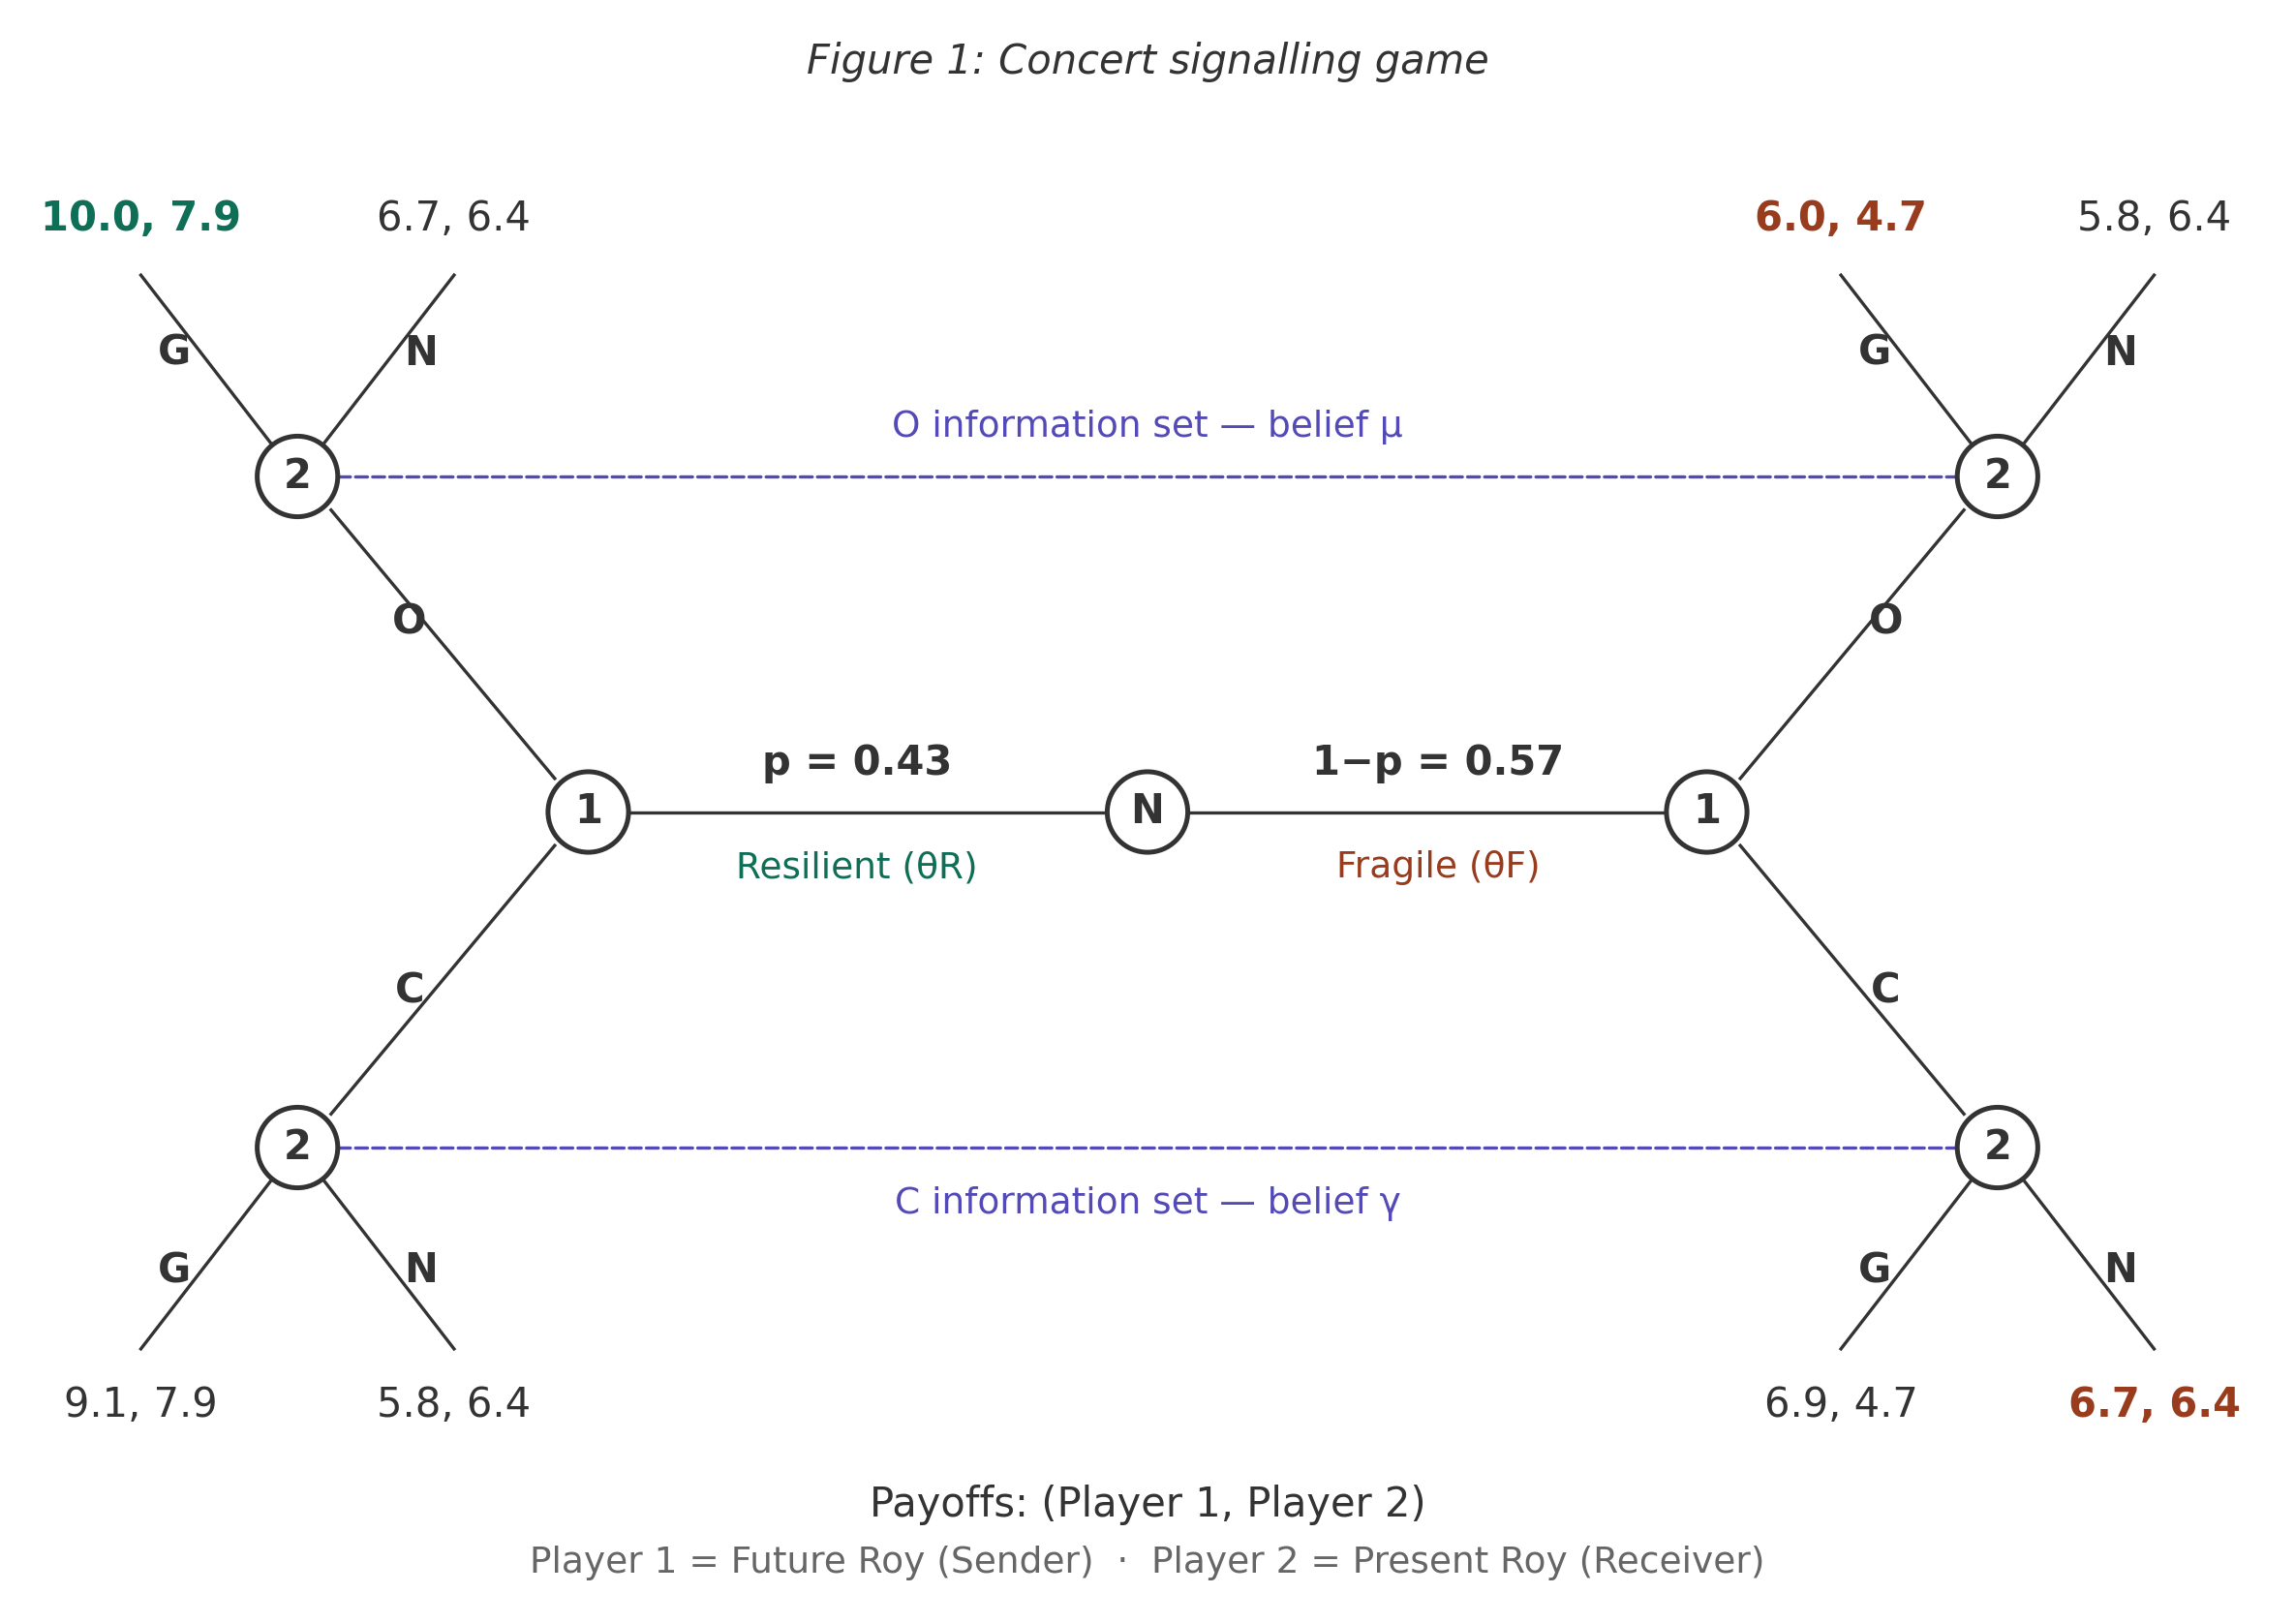

In [ ]:
"""
Game Tree Visualization — Concert Signalling Game
==================================================
Generates Figure 1 for the coursework: an extensive-form game tree
for the Bayesian signalling game between Present Roy and Future Roy.

Payoffs are data-driven, calibrated from the Kaggle Exam Score
Prediction dataset (n=9,878, moderate difficulty exams).

Usage:
    python game_tree.py

Output:
    game_tree.png (300 DPI, transparent background)

Author: Roy
Course: BASC0017 Interdisciplinary Game Theory
"""

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

# ── Attempt to use Aptos; fall back to Calibri then sans-serif ──
PREFERRED_FONTS = ['Aptos', 'Calibri', 'Arial', 'DejaVu Sans']
available = {f.name for f in fm.fontManager.ttflist}
FONT_FAMILY = next((f for f in PREFERRED_FONTS if f in available), 'sans-serif')

# ── Data-driven payoffs (from analysis_pipeline.py Section 5) ──
# Exam component (normalised 0-10)
E_R = 7.86   # Resilient + Go (concert night, score well)
E_F = 4.70   # Fragile + Go (concert night, score poorly)
E_N = 6.44   # Not Go (normal sleep, either type)

# Concert component (revealed preference)
C = 1.25     # Concert enjoyment: £100 / £800 budget × 10
L = 0.62     # Resale loss: £50 / £800 budget × 10

# Honesty bonus (from regression sleep quality gap)
h = 0.92     # (good_sleep_coef - poor_sleep_coef) / 10

# Player 1 payoffs: U(type, signal, action) = Exam + Concert + Honesty
P1 = {
    'R_O_G': E_R + C + h,    # Resilient, Optimistic, Go    = 10.0
    'R_O_N': E_N - L + h,    # Resilient, Optimistic, NotGo = 6.7
    'R_C_G': E_R + C,        # Resilient, Cautious, Go      = 9.1
    'R_C_N': E_N - L,        # Resilient, Cautious, NotGo   = 5.8
    'F_O_G': E_F + C,        # Fragile, Optimistic, Go      = 6.0
    'F_O_N': E_N - L,        # Fragile, Optimistic, NotGo   = 5.8
    'F_C_G': E_F + C + h,    # Fragile, Cautious, Go        = 6.9
    'F_C_N': E_N - L + h,    # Fragile, Cautious, NotGo     = 6.7
}

# Player 2 payoffs: depends on matching action to true type
P2 = {
    'R_G': E_R,   # Facing Resilient, Go    = 7.9
    'R_N': E_N,   # Facing Resilient, NotGo = 6.4
    'F_G': E_F,   # Facing Fragile, Go      = 4.7
    'F_N': E_N,   # Facing Fragile, NotGo   = 6.4
}

# Prior and threshold
p_prior = 0.43
mu_threshold = (E_N - E_F) / (E_R - E_F)  # ≈ 0.548

# ── Colour palette ──
GREEN  = '#0F6E56'   # Resilient type
ORANGE = '#993C1D'   # Fragile type
PURPLE = '#534AB7'   # Information sets
BLACK  = '#333333'   # Default text and lines
GRAY   = '#666666'   # Subtitle text

# ── Helper functions ──
def node(ax, x, y, label, size=10):
    """Draw a circular decision node."""
    circle = plt.Circle((x, y), 0.18, fill=True, facecolor='white',
                         edgecolor=BLACK, linewidth=1.2, zorder=5)
    ax.add_patch(circle)
    ax.text(x, y, label, ha='center', va='center', zorder=6,
            fontfamily=FONT_FAMILY, fontsize=size, fontweight='bold',
            color=BLACK)

def line(ax, x1, y1, x2, y2):
    """Draw a solid branch line."""
    ax.plot([x1, x2], [y1, y2], color=BLACK, linewidth=0.8, zorder=1)

def dashed_line(ax, x1, y1, x2, y2):
    """Draw a dashed information-set line."""
    ax.plot([x1, x2], [y1, y2], color=PURPLE, linewidth=0.8,
            linestyle='--', dash_capstyle='round', zorder=2)

def label(ax, x, y, text, size=10, color=BLACK, weight='normal', ha='center'):
    """Place a text label."""
    ax.text(x, y, text, ha=ha, va='center', fontfamily=FONT_FAMILY,
            fontsize=size, fontweight=weight, color=color)

def payoff_label(ax, x, y, p1_val, p2_val, color=BLACK, bold=False):
    """Place a payoff pair (P1, P2) label."""
    text = f"{p1_val:.1f}, {p2_val:.1f}"
    weight = 'bold' if bold else 'normal'
    ax.text(x, y, text, ha='center', va='center', fontfamily=FONT_FAMILY,
            fontsize=10, fontweight=weight, color=color)


def draw_game_tree(output_path='game_tree.png', dpi=300):
    """Draw the complete extensive-form game tree."""

    fig, ax = plt.subplots(1, 1, figsize=(10, 7))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 7)
    ax.set_aspect('equal')
    ax.axis('off')

    # ── Title ──
    ax.text(5, 6.8, 'Figure 1: Concert signalling game',
            ha='center', fontfamily=FONT_FAMILY, fontsize=10,
            fontstyle='italic', color=BLACK)

    # ── Nature node (centre) ──
    node(ax, 5, 3.5, 'N')

    # ── Player 1 nodes ──
    node(ax, 2.5, 3.5, '1')  # Resilient side
    node(ax, 7.5, 3.5, '1')  # Fragile side

    # ── Nature → Player 1 branches ──
    line(ax, 4.82, 3.5, 2.68, 3.5)
    line(ax, 5.18, 3.5, 7.32, 3.5)

    # Nature branch labels
    label(ax, 3.7, 3.72, f'p = {p_prior}', weight='bold')
    label(ax, 3.7, 3.25, 'Resilient (θR)', size=9, color=GREEN)
    label(ax, 6.3, 3.72, f'1−p = {1-p_prior:.2f}', weight='bold')
    label(ax, 6.3, 3.25, 'Fragile (θF)', size=9, color=ORANGE)

    # ── Player 2 nodes (four corners) ──
    node(ax, 1.2, 5.0, '2')   # Resilient + O (upper left)
    node(ax, 1.2, 2.0, '2')   # Resilient + C (lower left)
    node(ax, 8.8, 5.0, '2')   # Fragile + O (upper right)
    node(ax, 8.8, 2.0, '2')   # Fragile + C (lower right)

    # ── Player 1 → Player 2 signal branches ──
    line(ax, 2.35, 3.65, 1.35, 4.85)   # R → O
    line(ax, 2.35, 3.35, 1.35, 2.15)   # R → C
    line(ax, 7.65, 3.65, 8.65, 4.85)   # F → O
    line(ax, 7.65, 3.35, 8.65, 2.15)   # F → C

    # Signal labels
    label(ax, 1.7, 4.35, 'O', weight='bold')
    label(ax, 1.7, 2.7,  'C', weight='bold')
    label(ax, 8.3, 4.35, 'O', weight='bold')
    label(ax, 8.3, 2.7,  'C', weight='bold')

    # ── Information sets (dashed lines) ──
    dashed_line(ax, 1.38, 5.0, 8.62, 5.0)
    dashed_line(ax, 1.38, 2.0, 8.62, 2.0)

    # Information set labels
    label(ax, 5, 5.22, 'O information set — belief μ', size=9, color=PURPLE)
    label(ax, 5, 1.75, 'C information set — belief γ', size=9, color=PURPLE)

    # ── Terminal branches: Resilient + O (upper left) ──
    line(ax, 1.08, 5.15, 0.5, 5.9)
    line(ax, 1.32, 5.15, 1.9, 5.9)
    label(ax, 0.65, 5.55, 'G', weight='bold')
    label(ax, 1.75, 5.55, 'N', weight='bold')
    payoff_label(ax, 0.5, 6.15, P1['R_O_G'], P2['R_G'], color=GREEN, bold=True)
    payoff_label(ax, 1.9, 6.15, P1['R_O_N'], P2['R_N'])

    # ── Terminal branches: Resilient + C (lower left) ──
    line(ax, 1.08, 1.85, 0.5, 1.1)
    line(ax, 1.32, 1.85, 1.9, 1.1)
    label(ax, 0.65, 1.45, 'G', weight='bold')
    label(ax, 1.75, 1.45, 'N', weight='bold')
    payoff_label(ax, 0.5, 0.85, P1['R_C_G'], P2['R_G'])
    payoff_label(ax, 1.9, 0.85, P1['R_C_N'], P2['R_N'])

    # ── Terminal branches: Fragile + O (upper right) ──
    line(ax, 8.68, 5.15, 8.1, 5.9)
    line(ax, 8.92, 5.15, 9.5, 5.9)
    label(ax, 8.25, 5.55, 'G', weight='bold')
    label(ax, 9.35, 5.55, 'N', weight='bold')
    payoff_label(ax, 8.1, 6.15, P1['F_O_G'], P2['F_G'], color=ORANGE, bold=True)
    payoff_label(ax, 9.5, 6.15, P1['F_O_N'], P2['F_N'])

    # ── Terminal branches: Fragile + C (lower right) ──
    line(ax, 8.68, 1.85, 8.1, 1.1)
    line(ax, 8.92, 1.85, 9.5, 1.1)
    label(ax, 8.25, 1.45, 'G', weight='bold')
    label(ax, 9.35, 1.45, 'N', weight='bold')
    payoff_label(ax, 8.1, 0.85, P1['F_C_G'], P2['F_G'])
    payoff_label(ax, 9.5, 0.85, P1['F_C_N'], P2['F_N'], color=ORANGE, bold=True)

    # ── Bottom annotations ──
    ax.text(5, 0.35, 'Payoffs: (Player 1, Player 2)',
            ha='center', fontfamily=FONT_FAMILY, fontsize=10, color=BLACK)
    ax.text(5, 0.10, 'Player 1 = Future Roy (Sender)  ·  Player 2 = Present Roy (Receiver)',
            ha='center', fontfamily=FONT_FAMILY, fontsize=9, color=GRAY)

    # ── Save ──
    plt.savefig(output_path, dpi=dpi, transparent=True,
                bbox_inches='tight', pad_inches=0.1)
    plt.close()
    print(f"Game tree saved to {output_path} ({dpi} DPI, transparent background)")
    print(f"Font: {FONT_FAMILY}")
    print(f"\nPayoff summary:")
    print(f"  μ* = {mu_threshold:.3f}, p = {p_prior}")
    print(f"  Separating PBE: R→O (Go), F→C (Not Go)")


if __name__ == '__main__':
    draw_game_tree('game_tree.png', dpi=300)
draw_game_tree('game_tree.png', dpi=300)

from PIL import Image
from IPython.display import display

img = Image.open('game_tree.png')
display(img)